# Lung Pathlength Analysis — 763 nm vs 935 nm

Analysis of GASMAS Monte Carlo lung pathlengths, following the 8-step plan:

1. **Histograms** of lung pathlength distributions for both wavelengths, all SDS
2. **Combined boxplots** — both wavelengths in one plot per SDS
3. **Mean vs SDS** — comparison of distribution means
4. **Median ± IQR vs SDS** — central tendency with spread
5. **Comprehensive statistics table** — mean, median, std, IQR, skewness for all (SDS, wavelength) combinations
6. **Distribution similarity metrics** — KS test, Wasserstein distance, JS divergence, overlap coefficient
7. **GMM decomposition** — split each distribution into short- and long-path populations


## Environment Setup

In [ ]:
# Run once in Colab to mount Drive (skip if local)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab — using local paths.')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import lognorm, ks_2samp, wasserstein_distance
from sklearn.mixture import GaussianMixture

# Plot styling
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colors
C_763 = 'steelblue'    # 763 nm (O2)
C_935 = 'darkorange'   # 935 nm (H2O)


In [ ]:
# ── Global parameters ────────────────────────────────────────────
SDS_LIST_MM = [5, 10, 15, 20, 25, 30, 35]
DATA_ROOT   = '/content/drive/MyDrive/GASMAS_Corrected/External_H2O'

# Load detector data
data_ox    = np.load(f'{DATA_ROOT}/gasmas_simulation_results_20mm.npz')
data_water = np.load(f'{DATA_ROOT}/gasmas_H2O_simulation_results_20mm.npz')

detp_ox    = data_ox['detp']
detp_water = data_water['detp']

print(f'763 nm detp shape: {detp_ox.shape}')
print(f'935 nm detp shape: {detp_water.shape}')


763 nm detp shape: (4, 494443)
935 nm detp shape: (4, 545818)


##Helper functions


In [ ]:
def get_lung_pathlengths(detp, det_id):
    """Lung pathlengths (mm) for a given detector. Row index 2 = lung layer; ×0.1 to convert voxel units → mm."""
    mask = detp[0].astype(int) == det_id
    pl   = detp[2, mask] * 0.1
    return pl[pl > 0]


def collect_pathlengths(detp_ox, detp_water, sds_list=SDS_LIST_MM):
    """Return dict {sds: {'ox': array, 'water': array}} for every SDS that has photons."""
    out = {}
    det_ids = sorted(np.unique(detp_ox[0].astype(int)))
    for det_id in det_ids:
        if det_id - 1 >= len(sds_list):
            continue
        sds = sds_list[det_id - 1]
        out[sds] = {
            'ox':    get_lung_pathlengths(detp_ox,    det_id),
            'water': get_lung_pathlengths(detp_water, det_id),
        }
    return out


def basic_stats(pl):
    """Mean / median / std / IQR / skewness / n. Returns dict of NaN if empty."""
    if len(pl) < 2:
        return dict(n=len(pl), mean=np.nan, median=np.nan, std=np.nan,
                    iqr=np.nan, q25=np.nan, q75=np.nan, skew=np.nan)
    return dict(
        n      = len(pl),
        mean   = np.mean(pl),
        median = np.median(pl),
        std    = np.std(pl, ddof=1),
        iqr    = stats.iqr(pl),
        q25    = np.percentile(pl, 25),
        q75    = np.percentile(pl, 75),
        skew   = stats.skew(pl),
    )


def fit_gmm_log(pl, n_components=2, random_state=42):
    """Fit a 2-component GMM in log-space. Returns (gmm, labels, sorted_order).
       sorted_order[0] = short-path component label, [1] = long-path component label."""
    pl_pos = pl[pl > 0]
    if len(pl_pos) < 10:
        return None, None, None
    log_pl = np.log(pl_pos).reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, random_state=random_state, max_iter=500)
    gmm.fit(log_pl)
    labels = gmm.predict(log_pl)
    order  = np.argsort(gmm.means_.flatten())
    return gmm, labels, order


def split_gmm(pl):
    """Split a pathlength array into (short_paths, long_paths) using GMM in log space."""
    pl_pos = pl[pl > 0]
    gmm, labels, order = fit_gmm_log(pl_pos)
    if gmm is None:
        return np.array([]), np.array([])
    short = pl_pos[labels == order[0]]
    long_ = pl_pos[labels == order[1]]
    return short, long_


In [ ]:
# Build the master dictionary of pathlengths
PL = collect_pathlengths(detp_ox, detp_water)
print('SDS values with data:', list(PL.keys()))
for sds, d in PL.items():
    print(f'  SDS = {sds:>2} mm  →  n(763) = {len(d["ox"]):>7d}   n(935) = {len(d["water"]):>7d}')


SDS values with data: [5, 10, 15, 20, 25, 30, 35]
  SDS =  5 mm  →  n(763) =    2853   n(935) =    3785
  SDS = 10 mm  →  n(763) =    2550   n(935) =    3285
  SDS = 15 mm  →  n(763) =    2099   n(935) =    2773
  SDS = 20 mm  →  n(763) =    1573   n(935) =    2139
  SDS = 25 mm  →  n(763) =    1101   n(935) =    1563
  SDS = 30 mm  →  n(763) =     649   n(935) =     924
  SDS = 35 mm  →  n(763) =     370   n(935) =     522


##Histograms of lung pathlength


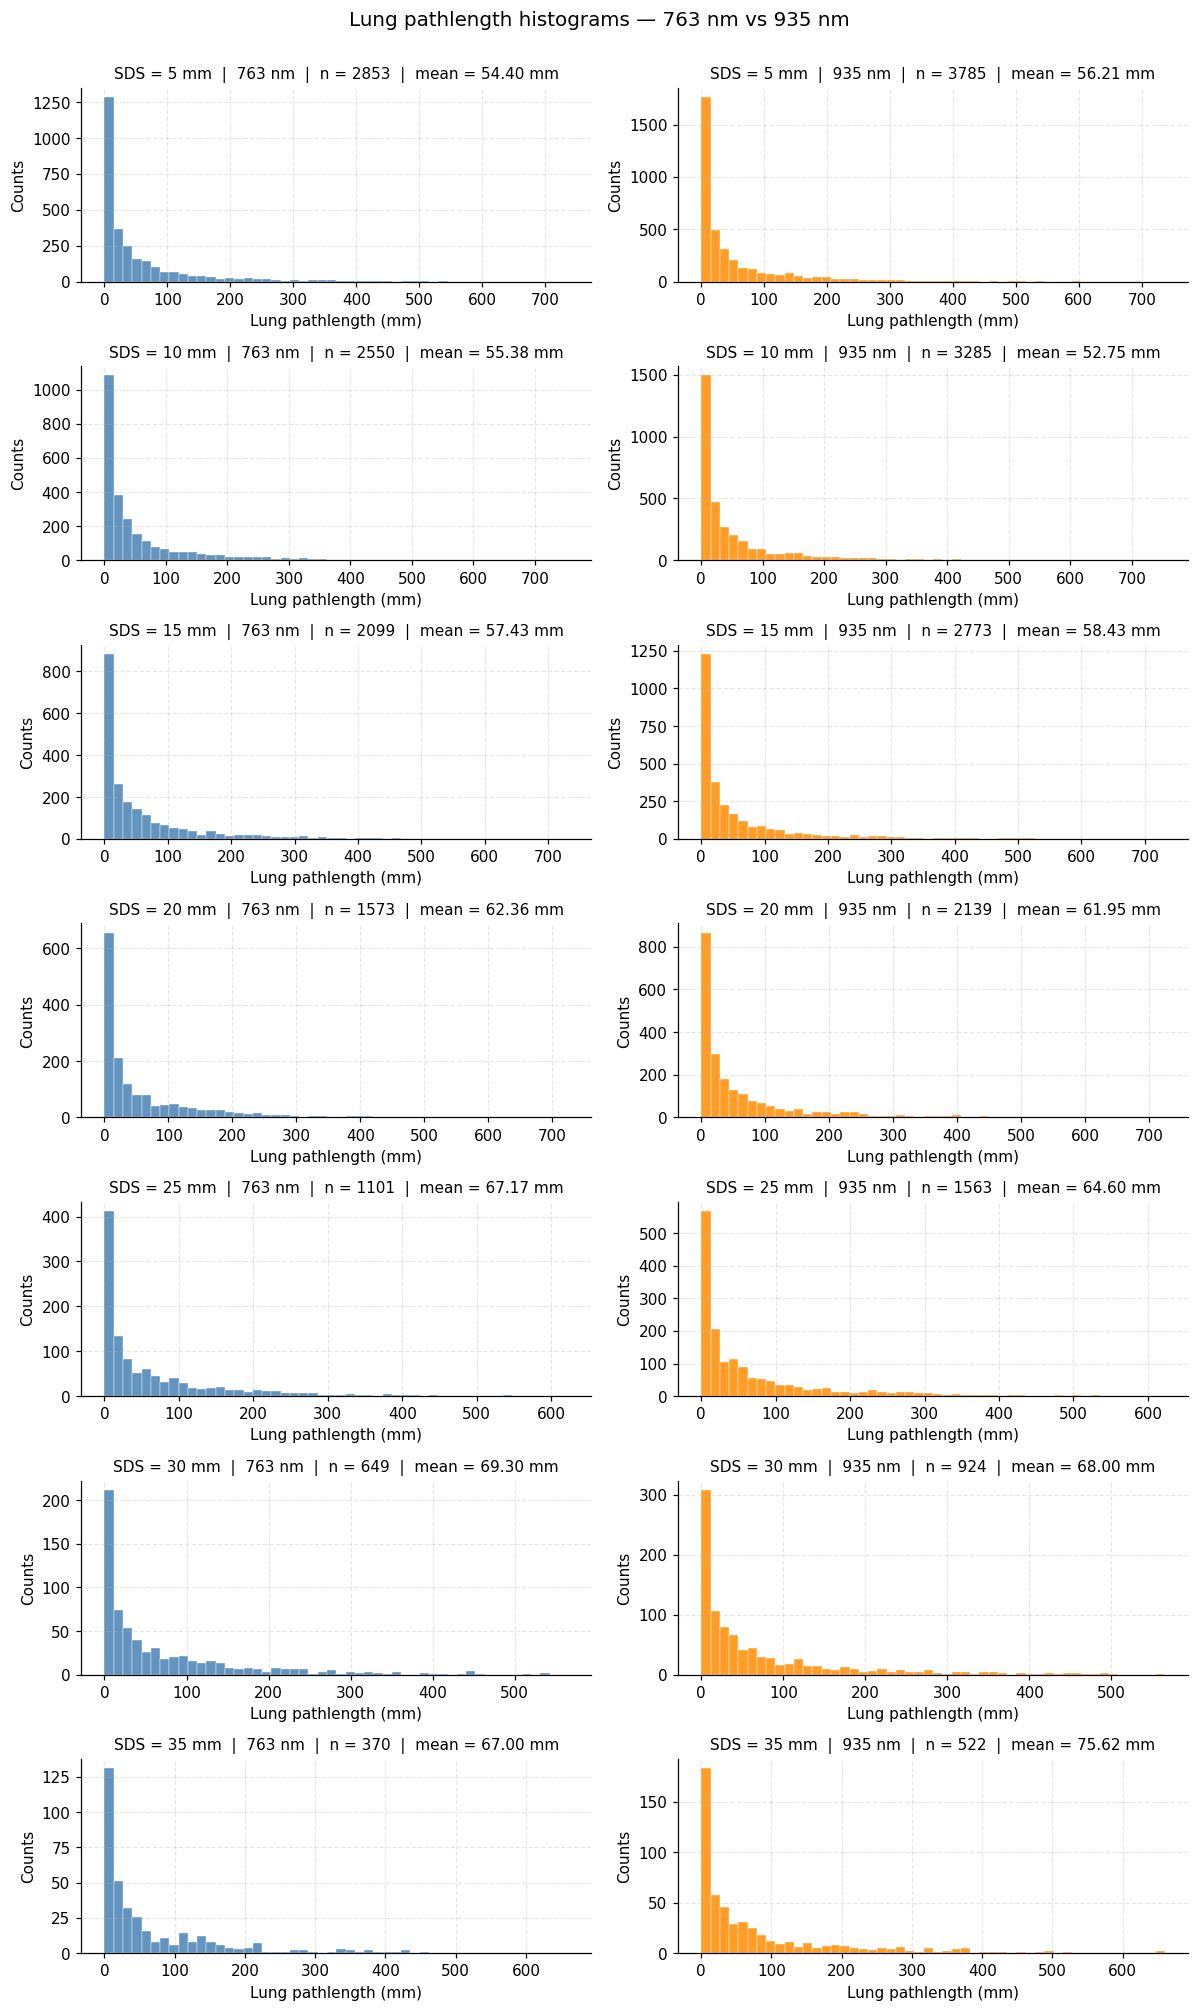

In [ ]:
def plot_histograms_grid(PL, bins=50):
    sds_values = list(PL.keys())
    n = len(sds_values)
    fig, axes = plt.subplots(n, 2, figsize=(11, 2.6 * n), squeeze=False)

    for i, sds in enumerate(sds_values):
        ox = PL[sds]['ox']
        wt = PL[sds]['water']

        ax_o = axes[i, 0]
        ax_w = axes[i, 1]

        if len(ox) == 0 and len(wt) == 0:
            for ax in (ax_o, ax_w):
                ax.text(0.5, 0.5, 'No photons reached lung',
                        ha='center', va='center', transform=ax.transAxes)
            continue

        all_pl = np.concatenate([ox, wt]) if len(ox) and len(wt) else (ox if len(ox) else wt)
        edges  = np.linspace(all_pl.min(), all_pl.max(), bins + 1)

        ax_o.hist(ox, bins=edges, color=C_763, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax_o.set_title(f'SDS = {sds} mm  |  763 nm  |  n = {len(ox)}  |  mean = {np.mean(ox):.2f} mm',
                       fontsize=10)
        ax_o.set_xlabel('Lung pathlength (mm)')
        ax_o.set_ylabel('Counts')

        ax_w.hist(wt, bins=edges, color=C_935, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax_w.set_title(f'SDS = {sds} mm  |  935 nm  |  n = {len(wt)}  |  mean = {np.mean(wt):.2f} mm',
                       fontsize=10)
        ax_w.set_xlabel('Lung pathlength (mm)')
        ax_w.set_ylabel('Counts')

    plt.suptitle('Lung pathlength histograms — 763 nm vs 935 nm', fontsize=13, y=1.002)
    plt.tight_layout()
    plt.show()


plot_histograms_grid(PL, bins=50)


## Combined boxplots (both wavelengths in one plot)


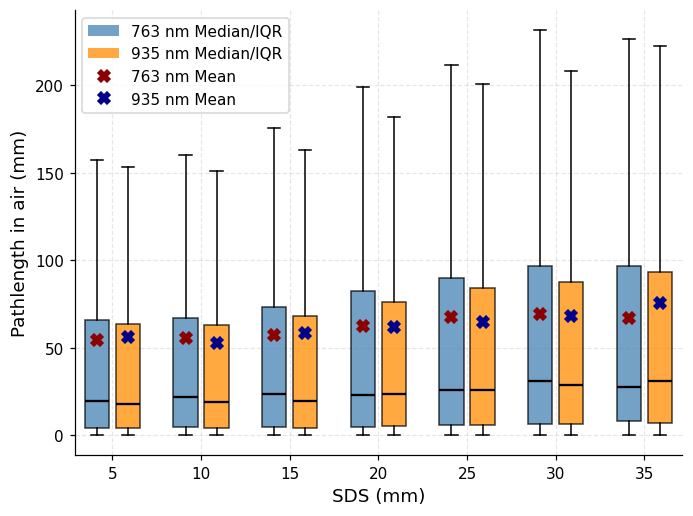

In [ ]:
def plot_combined_boxplots(PL, showfliers=False):
    sds_values = list(PL.keys())
    n          = len(sds_values)

    ox_data    = [PL[s]['ox']    for s in sds_values]
    water_data = [PL[s]['water'] for s in sds_values]

    # Calculate means for plotting
    ox_means    = [np.mean(d) if len(d) > 0 else np.nan for d in ox_data]
    water_means = [np.mean(d) if len(d) > 0 else np.nan for d in water_data]

    fig, ax = plt.subplots()

    positions_ox    = np.arange(n) * 2.0
    positions_water = positions_ox + 0.7

    bp_o = ax.boxplot(ox_data, positions=positions_ox, widths=0.55,
                      patch_artist=True,
                      boxprops=dict(facecolor=C_763, alpha=0.75, edgecolor='black'),
                      medianprops=dict(color='black', linewidth=1.5),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'),
                      showfliers=showfliers)
    bp_w = ax.boxplot(water_data, positions=positions_water, widths=0.55,
                      patch_artist=True,
                      boxprops=dict(facecolor=C_935, alpha=0.75, edgecolor='black'),
                      medianprops=dict(color='black', linewidth=1.5),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'),
                      showfliers=showfliers)

    # Plot mean markers
    ax.plot(positions_ox,    ox_means,    'X', color='darkred', markersize=8, label='763 nm Mean')
    ax.plot(positions_water, water_means, 'X', color='darkblue', markersize=8, label='935 nm Mean')

    ax.set_xticks(positions_ox + 0.35)
    ax.set_xticklabels([str(s) for s in sds_values])
    ax.set_xlabel('SDS (mm)',fontsize=12)
    ax.set_ylabel('Pathlength in air (mm)',fontsize=12)
    #ax.set_title('Lung pathlength distribution vs SDS — 763 nm vs 935 nm')
    ax.legend([Patch(facecolor=C_763, alpha=0.75),
               Patch(facecolor=C_935, alpha=0.75),
               plt.Line2D([0], [0], marker='X', color='darkred', linestyle='None', markersize=8),
               plt.Line2D([0], [0], marker='X', color='darkblue', linestyle='None', markersize=8)],
              ['763 nm Median/IQR', '935 nm Median/IQR', '763 nm Mean', '935 nm Mean'], loc='upper left')
    plt.tight_layout()
    plt.show()


plot_combined_boxplots(PL)

##Mean pathlength vs SDS


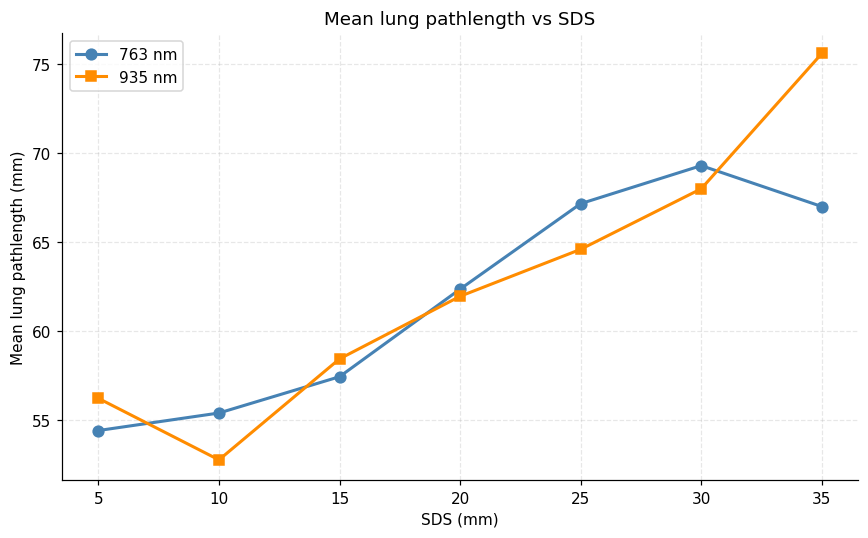

In [ ]:
def plot_mean_vs_sds(PL):
    sds_values  = list(PL.keys())
    ox_means    = [np.mean(PL[s]['ox'])    if len(PL[s]['ox'])    else np.nan for s in sds_values]
    water_means = [np.mean(PL[s]['water']) if len(PL[s]['water']) else np.nan for s in sds_values]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sds_values, ox_means,    'o-', color=C_763, label='763 nm', linewidth=2, markersize=7)
    ax.plot(sds_values, water_means, 's-', color=C_935, label='935 nm', linewidth=2, markersize=7)
    ax.set_xlabel('SDS (mm)')
    ax.set_ylabel('Mean lung pathlength (mm)')
    ax.set_title('Mean lung pathlength vs SDS')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_mean_vs_sds(PL)


##Median pathlength with IQR band vs SDS


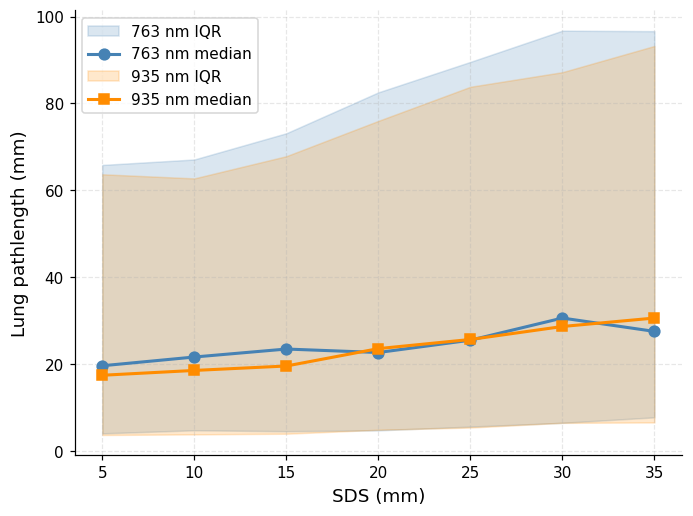

In [ ]:
def plot_median_iqr_vs_sds(PL):
    sds_values = list(PL.keys())

    def med_iqr(arr):
        if len(arr) < 2:
            return np.nan, np.nan, np.nan
        return np.median(arr), np.percentile(arr, 25), np.percentile(arr, 75)

    ox  = np.array([med_iqr(PL[s]['ox'])    for s in sds_values])
    wat = np.array([med_iqr(PL[s]['water']) for s in sds_values])

    fig, ax = plt.subplots()

    ax.fill_between(sds_values, ox[:, 1],  ox[:, 2],  color=C_763, alpha=0.20, label='763 nm IQR')
    ax.plot(sds_values,         ox[:, 0],  'o-', color=C_763, linewidth=2, markersize=7, label='763 nm median')

    ax.fill_between(sds_values, wat[:, 1], wat[:, 2], color=C_935, alpha=0.20, label='935 nm IQR')
    ax.plot(sds_values,         wat[:, 0], 's-', color=C_935, linewidth=2, markersize=7, label='935 nm median')

    ax.set_xlabel('SDS (mm)',fontsize=12)
    ax.set_ylabel('Lung pathlength (mm)',fontsize=12)
    #ax.set_title('Median ± IQR of lung pathlength vs SDS')
    ax.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    plt.show()


plot_median_iqr_vs_sds(PL)


##Comprehensive statistics table

For every SDS and both wavelengths: **n, mean, median, std, IQR, skewness**.


In [ ]:
def build_stats_table(PL):
    rows = []
    for sds, d in PL.items():
        for label, arr in [('763 nm', d['ox']), ('935 nm', d['water'])]:
            s = basic_stats(arr)
            rows.append({
                'SDS (mm)' : sds,
                'Wavelength' : label,
                'n'        : s['n'],
                'mean'     : s['mean'],
                'median'   : s['median'],
                'std'      : s['std'],
                'IQR'      : s['iqr'],
                'Q25'      : s['q25'],
                'Q75'      : s['q75'],
                'skewness' : s['skew'],
            })
    df = pd.DataFrame(rows)
    return df


stats_df = build_stats_table(PL)
display(stats_df.style.format({
    'mean': '{:.3f}', 'median': '{:.3f}', 'std': '{:.3f}',
    'IQR': '{:.3f}', 'Q25': '{:.3f}', 'Q75': '{:.3f}',
    'skewness': '{:.3f}',
}).set_caption('Lung pathlength statistics — all SDS, both wavelengths'))


,SDS (mm),Wavelength,n,mean,median,std,IQR,Q25,Q75,skewness
0,5,763 nm,2853,54.399,19.652,84.599,61.752,4.096,65.848,2.631
1,5,935 nm,3785,56.211,17.465,90.721,59.977,3.726,63.703,2.767
2,10,763 nm,2550,55.384,21.663,83.730,62.292,4.810,67.102,2.609
3,10,935 nm,3285,52.748,18.575,84.430,58.889,3.864,62.753,2.955
4,15,763 nm,2099,57.427,23.499,83.060,68.544,4.593,73.137,2.392
5,15,935 nm,2773,58.430,19.594,94.207,63.846,4.017,67.863,2.798
6,20,763 nm,1573,62.355,22.698,91.712,77.763,4.784,82.548,2.470
7,20,935 nm,2139,61.953,23.594,92.962,71.062,4.922,75.984,2.574
8,25,763 nm,1101,67.166,25.534,96.829,83.904,5.650,89.554,2.398
9,25,935 nm,1563,64.595,25.698,92.162,78.390,5.438,83.829,2.343


## Step 6 — Distribution similarity (763 nm ↔ 935 nm)

For every SDS we compare the two wavelengths' distributions using:

- **KS statistic** — max distance between empirical CDFs (smaller = more similar). p-value tests the null "same distribution".
- **Wasserstein (Earth Mover's) distance** — average distance to move probability mass from one distribution to the other, in mm.
- **Jensen–Shannon divergence** — symmetric KL-based divergence (0 = identical, log(2) ≈ 0.693 = maximally different) computed on shared histogram bins.
- **Overlap coefficient** — fraction of histogram area shared between the two distributions (0 = disjoint, 1 = identical).


In [ ]:
def js_divergence(p, q, eps=1e-12):
    p = p + eps; q = q + eps
    p = p / p.sum(); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))


def overlap_coefficient(a, b, bins=80):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan, np.nan
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    edges = np.linspace(lo, hi, bins + 1)
    pa, _ = np.histogram(a, bins=edges, density=True)
    pb, _ = np.histogram(b, bins=edges, density=True)
    bin_w = edges[1] - edges[0]
    pa *= bin_w; pb *= bin_w   # normalize to probabilities
    overlap = np.minimum(pa, pb).sum()
    js      = js_divergence(pa, pb)
    return overlap, js, bin_w


def build_similarity_table(PL):
    rows = []
    for sds, d in PL.items():
        a, b = d['ox'], d['water']
        if len(a) < 5 or len(b) < 5:
            rows.append({'SDS (mm)': sds, 'KS stat': np.nan, 'KS p-value': np.nan,
                         'Wasserstein (mm)': np.nan, 'JS divergence': np.nan,
                         'Overlap coeff.': np.nan})
            continue
        ks = ks_2samp(a, b)
        wd = wasserstein_distance(a, b)
        ov, js, _ = overlap_coefficient(a, b)
        rows.append({
            'SDS (mm)'          : sds,
            'KS stat'           : ks.statistic,
            'KS p-value'        : ks.pvalue,
            'Wasserstein (mm)'  : wd,
            'JS divergence'     : js,
            'Overlap coeff.'    : ov,
        })
    return pd.DataFrame(rows)


sim_df = build_similarity_table(PL)
display(sim_df.style.format({
    'KS stat': '{:.4f}', 'KS p-value': '{:.2e}',
    'Wasserstein (mm)': '{:.4f}', 'JS divergence': '{:.4f}',
    'Overlap coeff.': '{:.4f}',
}).set_caption('763 nm vs 935 nm — distribution similarity per SDS'))


,SDS (mm),KS stat,KS p-value,Wasserstein (mm),JS divergence,Overlap coeff.
0,5,0.0242,2.92e-01,3.5483,0.0068,0.9381
1,10,0.0381,2.99e-02,3.5549,0.0068,0.9336
2,15,0.0419,2.88e-02,5.4039,0.0108,0.9251
3,20,0.0257,5.76e-01,3.0406,0.0091,0.9319
4,25,0.0316,5.27e-01,3.5365,0.0163,0.9179
5,30,0.0357,6.99e-01,2.9944,0.0245,0.8825
6,35,0.0484,6.68e-01,9.2736,0.0396,0.8237


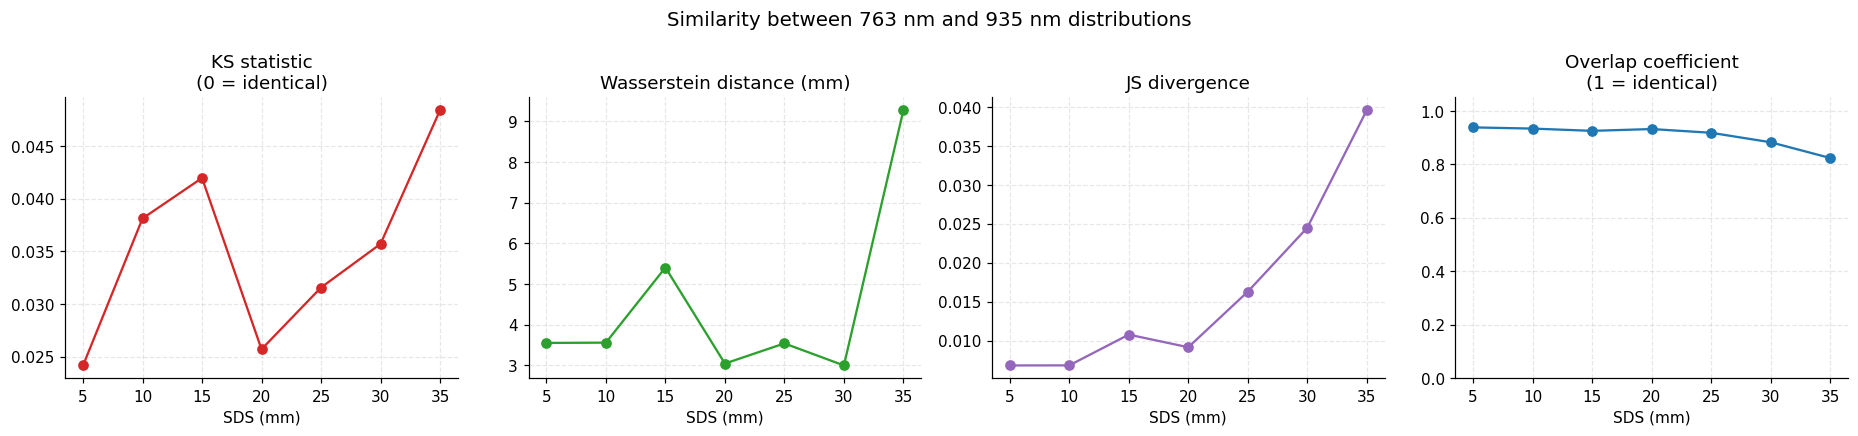

In [ ]:
# Visualize the similarity metrics
def plot_similarity_metrics(sim_df):
    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    axes[0].plot(sim_df['SDS (mm)'], sim_df['KS stat'],          'o-', color='C3')
    axes[0].set_title('KS statistic\n(0 = identical)');         axes[0].set_xlabel('SDS (mm)')

    axes[1].plot(sim_df['SDS (mm)'], sim_df['Wasserstein (mm)'], 'o-', color='C2')
    axes[1].set_title('Wasserstein distance (mm)');             axes[1].set_xlabel('SDS (mm)')

    axes[2].plot(sim_df['SDS (mm)'], sim_df['JS divergence'],    'o-', color='C4')
    axes[2].set_title('JS divergence');                          axes[2].set_xlabel('SDS (mm)')

    axes[3].plot(sim_df['SDS (mm)'], sim_df['Overlap coeff.'],   'o-', color='C0')
    axes[3].set_title('Overlap coefficient\n(1 = identical)'); axes[3].set_xlabel('SDS (mm)')
    axes[3].set_ylim(0, 1.05)

    plt.suptitle('Similarity between 763 nm and 935 nm distributions', fontsize=13)
    plt.tight_layout()
    plt.show()


plot_similarity_metrics(sim_df)


## Step 7 — GMM decomposition into short / long pathlengths


In [ ]:
def split_all_gmm(PL):
    """Return dict {sds: {'ox_short','ox_long','water_short','water_long'}}"""
    out = {}
    for sds, d in PL.items():
        s_ox, l_ox = split_gmm(d['ox'])
        s_wt, l_wt = split_gmm(d['water'])
        out[sds] = {
            'ox_short':    s_ox, 'ox_long':    l_ox,
            'water_short': s_wt, 'water_long': l_wt,
        }
    return out


PL_split = split_all_gmm(PL)
print('GMM populations extracted. Per-SDS sample counts:')
for sds, d in PL_split.items():
    print(f'  SDS = {sds:>2} mm | 763: short={len(d["ox_short"]):>6d}  long={len(d["ox_long"]):>6d}'
          f'   |  935: short={len(d["water_short"]):>6d}  long={len(d["water_long"]):>6d}')


GMM populations extracted. Per-SDS sample counts:
  SDS =  5 mm | 763: short=   656  long=  2197   |  935: short=   912  long=  2873
  SDS = 10 mm | 763: short=   568  long=  1982   |  935: short=   781  long=  2504
  SDS = 15 mm | 763: short=   639  long=  1460   |  935: short=   675  long=  2098
  SDS = 20 mm | 763: short=   422  long=  1151   |  935: short=   518  long=  1621
  SDS = 25 mm | 763: short=   286  long=   815   |  935: short=   350  long=  1213
  SDS = 30 mm | 763: short=   156  long=   493   |  935: short=   204  long=   720
  SDS = 35 mm | 763: short=    92  long=   278   |  935: short=   151  long=   371


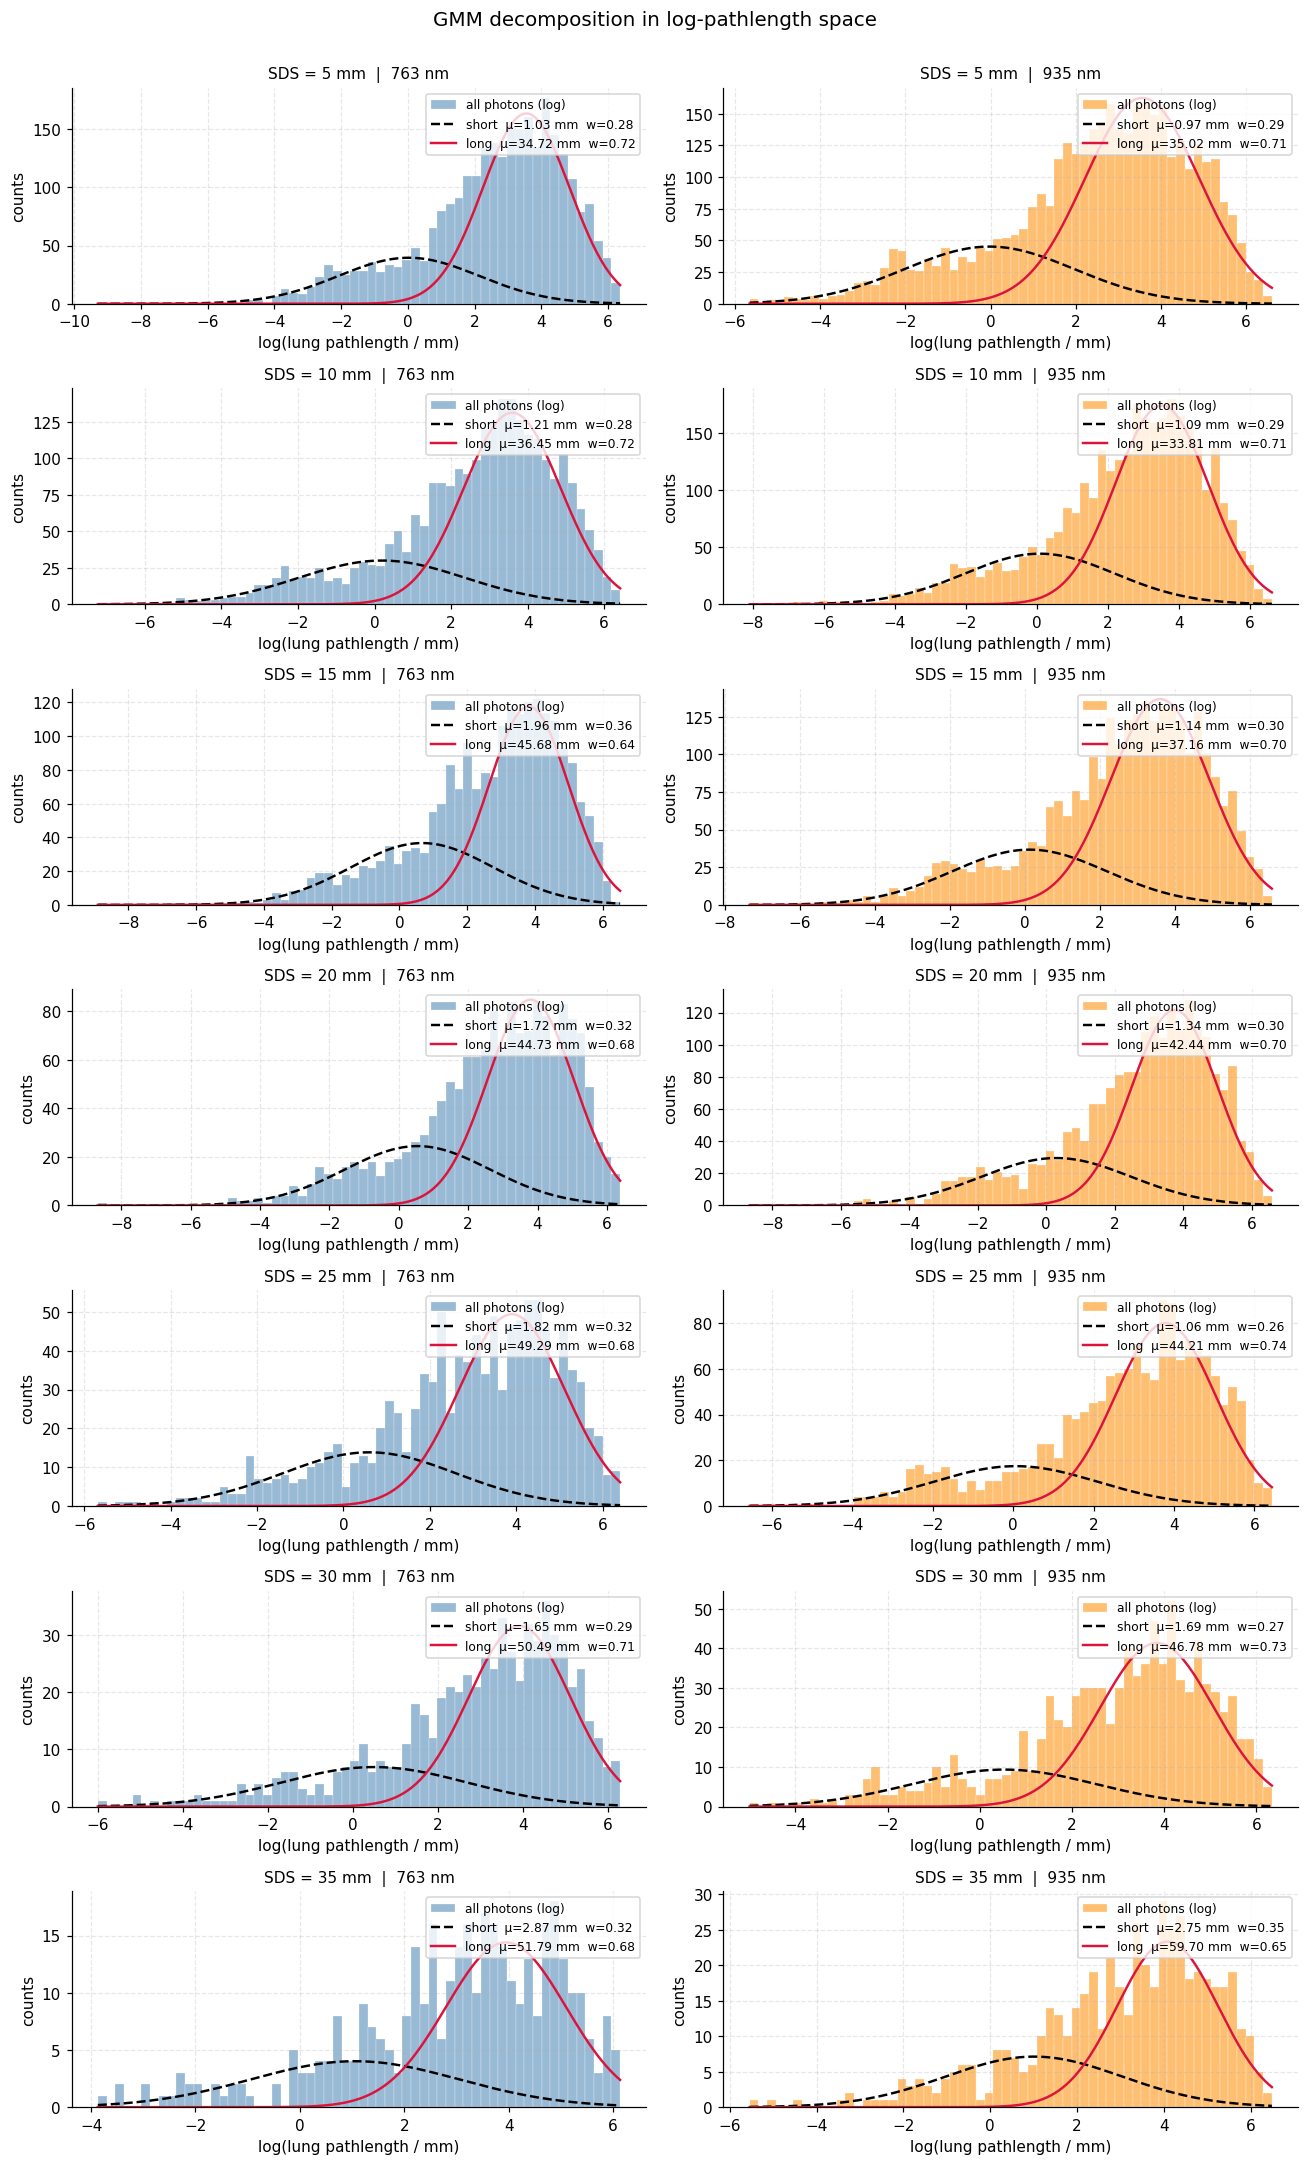

In [ ]:
def plot_gmm_decomposition(PL, bins=60):
    sds_values = list(PL.keys())
    n = len(sds_values)
    fig, axes = plt.subplots(n, 2, figsize=(12, 2.8 * n), squeeze=False)

    for i, sds in enumerate(sds_values):
        for j, (label, color, key) in enumerate([('763 nm', C_763, 'ox'), ('935 nm', C_935, 'water')]):
            ax = axes[i, j]
            pl = PL[sds][key]
            if len(pl) < 10:
                ax.text(0.5, 0.5, 'too few photons', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'SDS = {sds} mm  |  {label}')
                continue

            pl_pos = pl[pl > 0]
            log_pl = np.log(pl_pos)
            gmm, labels, order = fit_gmm_log(pl_pos)

            counts, edges, _ = ax.hist(log_pl, bins=bins, color=color, alpha=0.55,
                                       edgecolor='white', linewidth=0.3, label='all photons (log)')
            bin_w = edges[1] - edges[0]

            x = np.linspace(log_pl.min(), log_pl.max(), 400)
            for k, comp_name in enumerate(['short', 'long']):
                comp = order[k]
                mu   = gmm.means_.flatten()[comp]
                sig  = np.sqrt(gmm.covariances_.flatten()[comp])
                w    = gmm.weights_[comp]
                pdf  = w * (1/(sig*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sig)**2)
                ax.plot(x, pdf * len(pl_pos) * bin_w,
                        linestyle='--' if comp_name == 'short' else '-',
                        color='black' if comp_name == 'short' else 'crimson',
                        linewidth=1.6,
                        label=f'{comp_name}  μ={np.exp(mu):.2f} mm  w={w:.2f}')

            ax.set_xlabel('log(lung pathlength / mm)')
            ax.set_ylabel('counts')
            ax.set_title(f'SDS = {sds} mm  |  {label}', fontsize=10)
            ax.legend(fontsize=8, loc='upper right')

    plt.suptitle('GMM decomposition in log-pathlength space', fontsize=13, y=1.002)
    plt.tight_layout()
    plt.show()


plot_gmm_decomposition(PL)


##Repeat steps 1–6 for the GMM-separated short / long populations


### 8.1 Histograms of short / long components

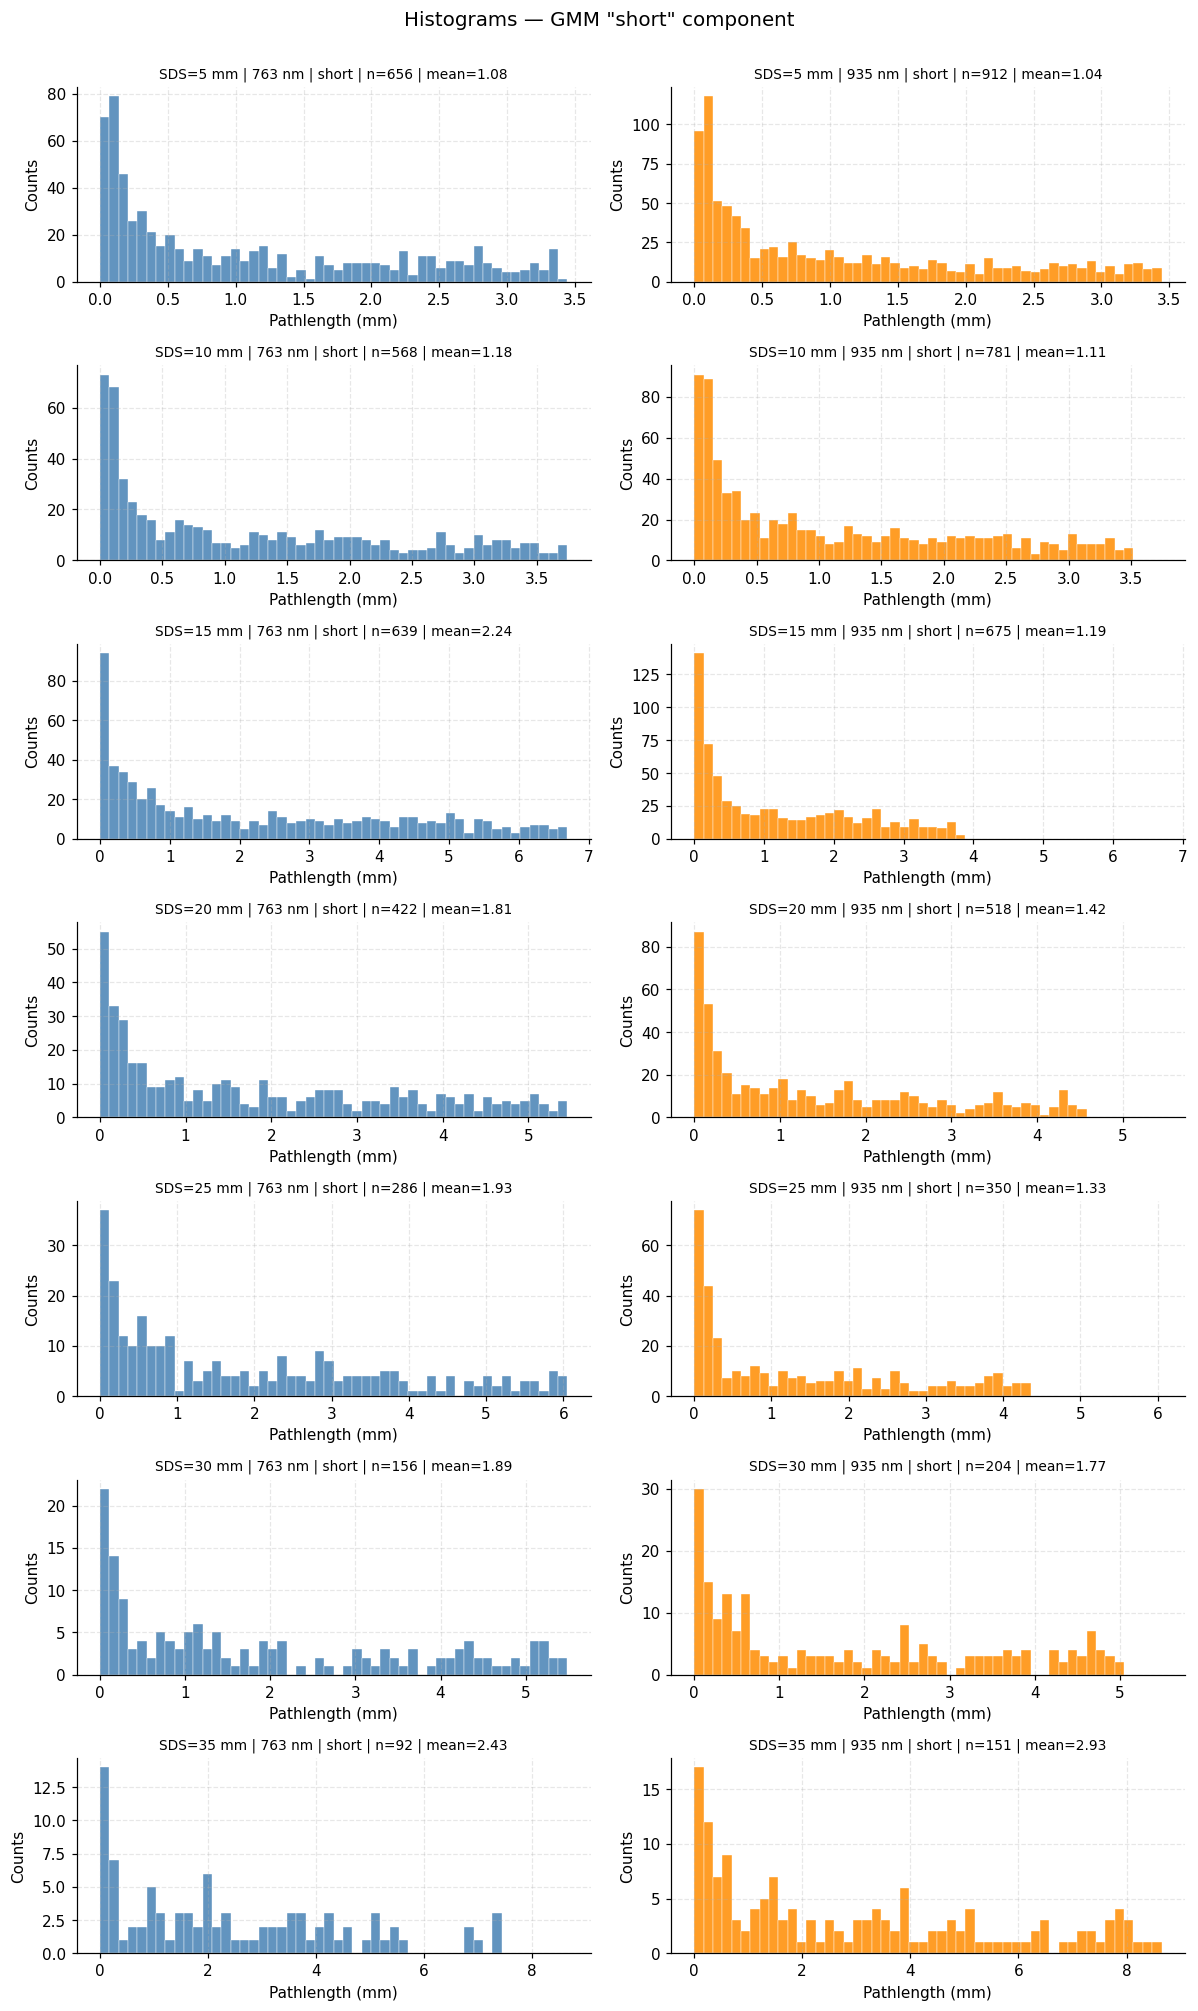

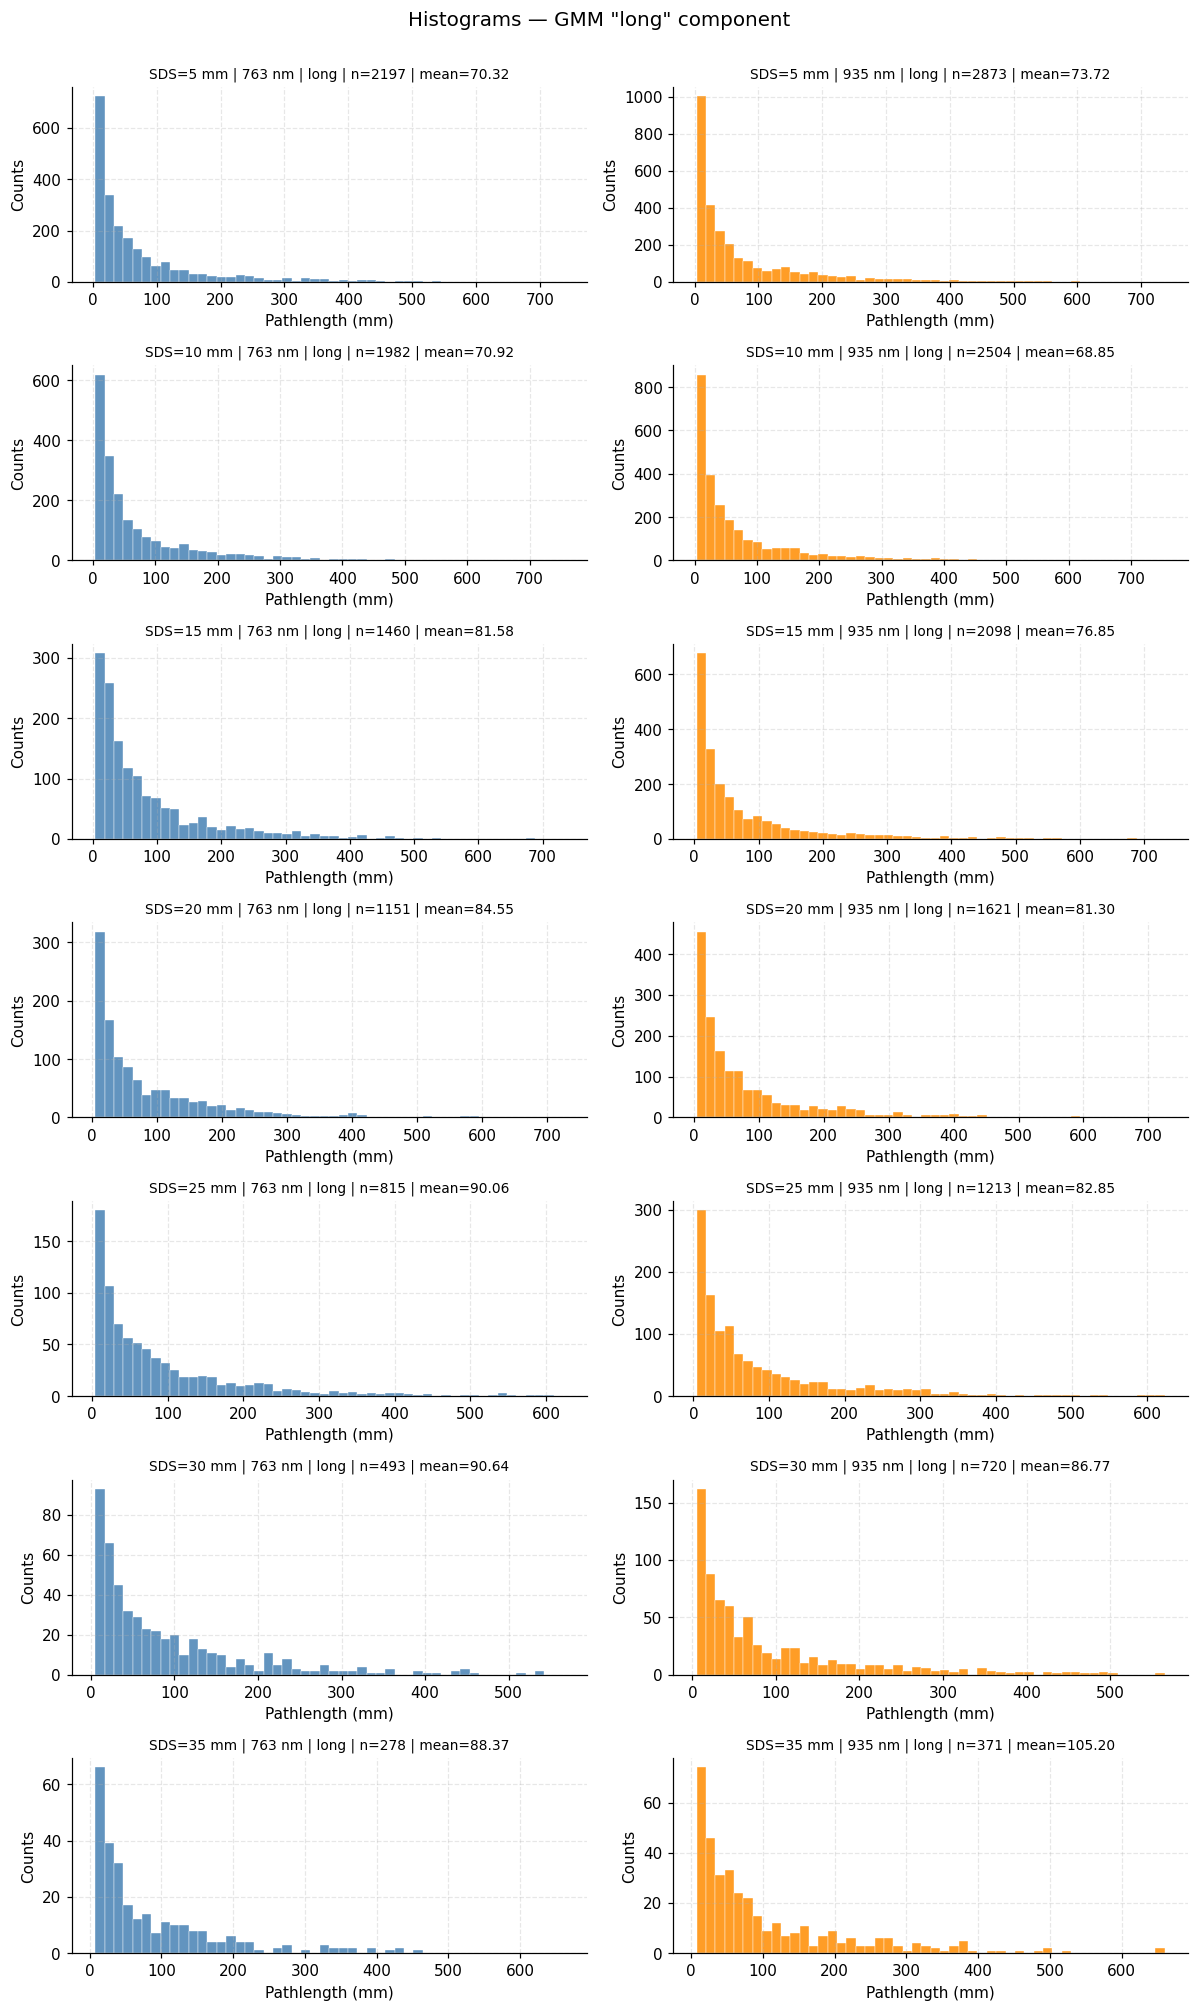

In [ ]:
def plot_split_histograms(PL_split, component='short', bins=50):
    sds_values = list(PL_split.keys())
    n = len(sds_values)
    fig, axes = plt.subplots(n, 2, figsize=(11, 2.6 * n), squeeze=False)

    for i, sds in enumerate(sds_values):
        ox = PL_split[sds][f'ox_{component}']
        wt = PL_split[sds][f'water_{component}']

        ax_o, ax_w = axes[i, 0], axes[i, 1]

        if len(ox) == 0 and len(wt) == 0:
            for ax in (ax_o, ax_w):
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            continue
        all_pl = np.concatenate([ox, wt]) if len(ox) and len(wt) else (ox if len(ox) else wt)
        edges = np.linspace(all_pl.min(), all_pl.max(), bins + 1)

        ax_o.hist(ox, bins=edges, color=C_763, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax_o.set_title(f'SDS={sds} mm | 763 nm | {component} | n={len(ox)} | mean={np.mean(ox) if len(ox) else np.nan:.2f}',
                       fontsize=9)
        ax_o.set_xlabel('Pathlength (mm)'); ax_o.set_ylabel('Counts')

        ax_w.hist(wt, bins=edges, color=C_935, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax_w.set_title(f'SDS={sds} mm | 935 nm | {component} | n={len(wt)} | mean={np.mean(wt) if len(wt) else np.nan:.2f}',
                       fontsize=9)
        ax_w.set_xlabel('Pathlength (mm)'); ax_w.set_ylabel('Counts')

    plt.suptitle(f'Histograms — GMM "{component}" component', fontsize=13, y=1.002)
    plt.tight_layout()
    plt.show()


plot_split_histograms(PL_split, component='short')
plot_split_histograms(PL_split, component='long')


### 8.2 Boxplots — short and long, both wavelengths

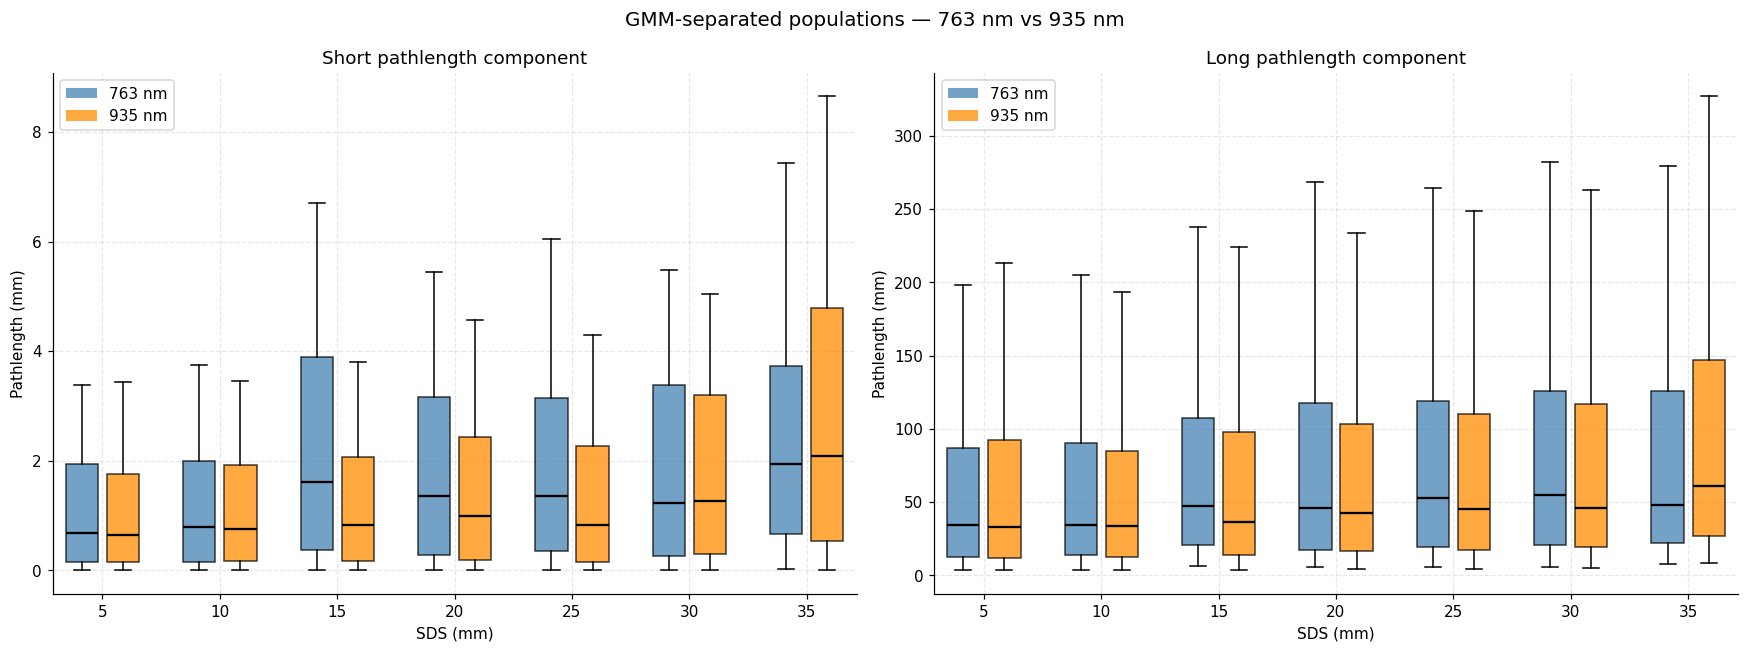

In [ ]:
def plot_split_boxplots(PL_split, showfliers=False):
    sds_values = list(PL_split.keys())
    n = len(sds_values)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, component, title in zip(axes, ['short', 'long'],
                                    ['Short pathlength component', 'Long pathlength component']):
        ox_data = [PL_split[s][f'ox_{component}']    for s in sds_values]
        wt_data = [PL_split[s][f'water_{component}'] for s in sds_values]

        pos_o = np.arange(n) * 2.0
        pos_w = pos_o + 0.7

        bp_o = ax.boxplot(ox_data, positions=pos_o, widths=0.55, patch_artist=True,
                          boxprops=dict(facecolor=C_763, alpha=0.75),
                          medianprops=dict(color='black', linewidth=1.5),
                          showfliers=showfliers)
        bp_w = ax.boxplot(wt_data, positions=pos_w, widths=0.55, patch_artist=True,
                          boxprops=dict(facecolor=C_935, alpha=0.75),
                          medianprops=dict(color='black', linewidth=1.5),
                          showfliers=showfliers)
        ax.set_xticks(pos_o + 0.35)
        ax.set_xticklabels([str(s) for s in sds_values])
        ax.set_xlabel('SDS (mm)')
        ax.set_ylabel('Pathlength (mm)')
        ax.set_title(title)
        ax.legend([Patch(facecolor=C_763, alpha=0.75),
                   Patch(facecolor=C_935, alpha=0.75)],
                  ['763 nm', '935 nm'], loc='upper left')

    plt.suptitle('GMM-separated populations — 763 nm vs 935 nm', fontsize=13)
    plt.tight_layout()
    plt.show()


plot_split_boxplots(PL_split)


In [ ]:
sds = 35
print('full max:', PL[sds]['ox'].max())
print('long max:', PL_split[sds]['ox_long'].max())
# These should be exactly equal

full max: 461.15387
long max: 461.15387


### 8.3 Mean vs SDS — short and long components

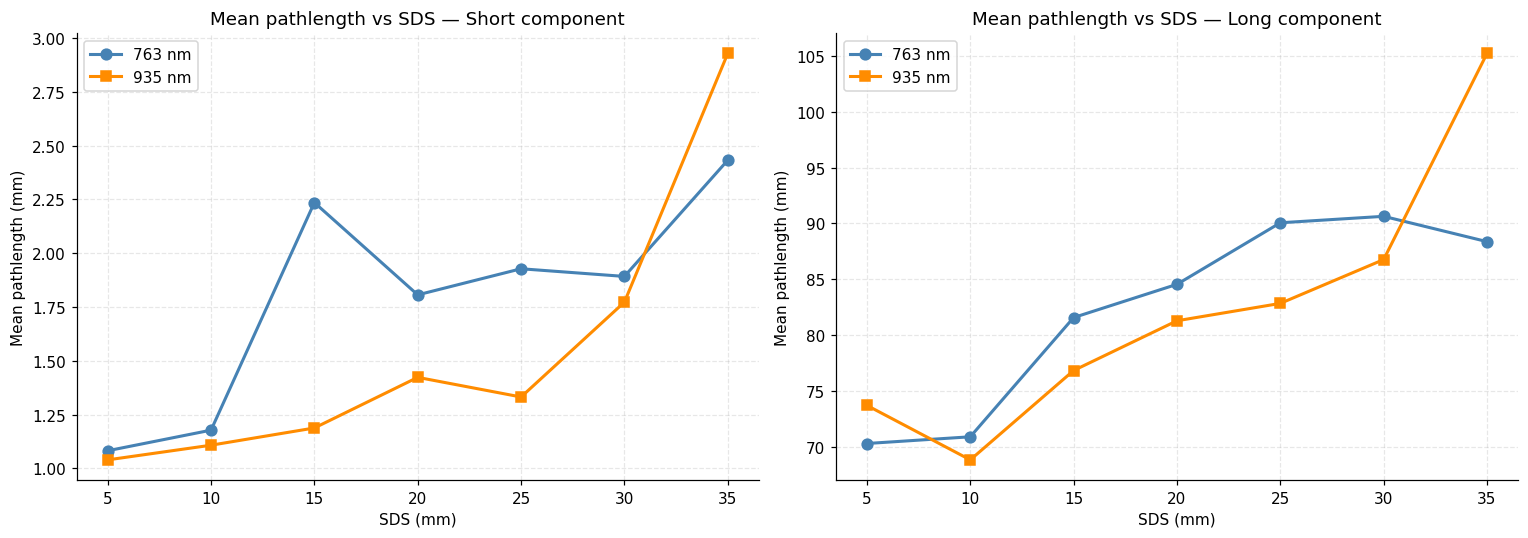

In [ ]:
def plot_split_means_vs_sds(PL_split):
    sds_values = list(PL_split.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, component, title in zip(axes, ['short', 'long'],
                                    ['Short component', 'Long component']):
        ox_mean = [np.mean(PL_split[s][f'ox_{component}'])    if len(PL_split[s][f'ox_{component}'])    else np.nan for s in sds_values]
        wt_mean = [np.mean(PL_split[s][f'water_{component}']) if len(PL_split[s][f'water_{component}']) else np.nan for s in sds_values]
        ax.plot(sds_values, ox_mean, 'o-', color=C_763, label='763 nm', linewidth=2, markersize=7)
        ax.plot(sds_values, wt_mean, 's-', color=C_935, label='935 nm', linewidth=2, markersize=7)
        ax.set_xlabel('SDS (mm)'); ax.set_ylabel('Mean pathlength (mm)')
        ax.set_title(f'Mean pathlength vs SDS — {title}')
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_split_means_vs_sds(PL_split)


### 8.4 Median ± IQR — short and long components

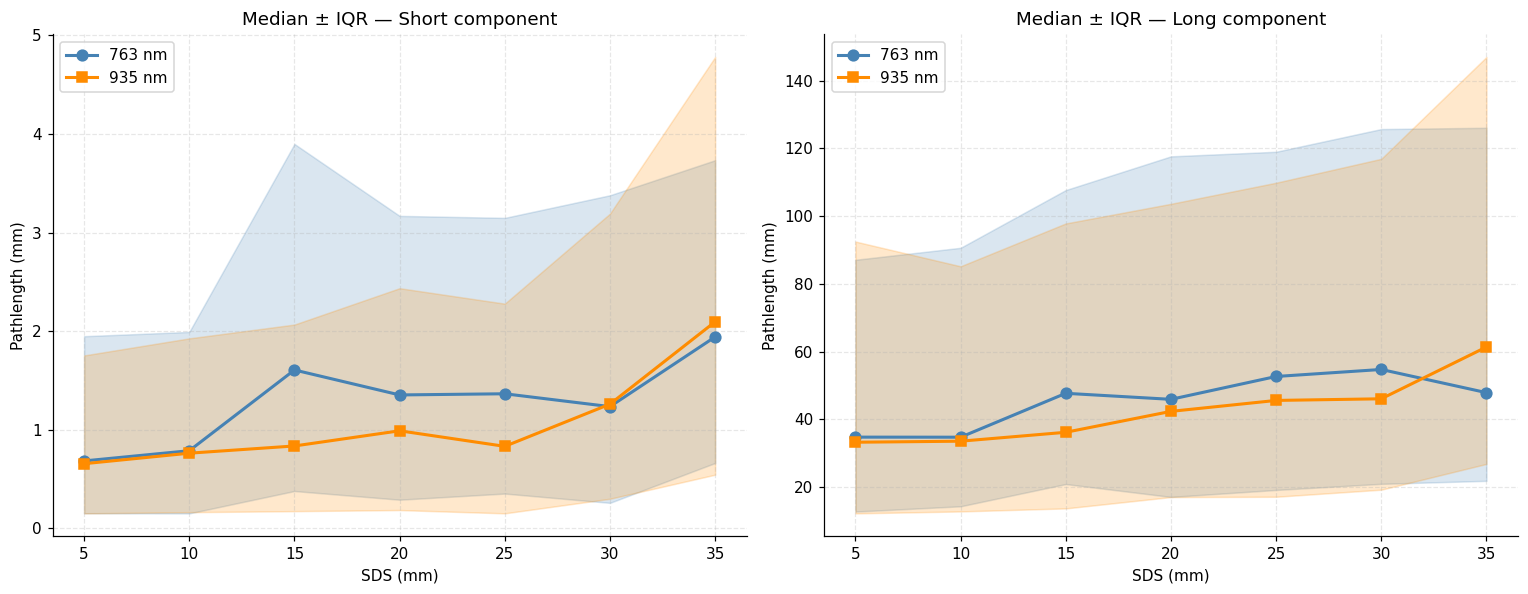

In [ ]:
def plot_split_median_iqr(PL_split):
    sds_values = list(PL_split.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    def med_iqr(arr):
        if len(arr) < 2:
            return np.nan, np.nan, np.nan
        return np.median(arr), np.percentile(arr, 25), np.percentile(arr, 75)

    for ax, component, title in zip(axes, ['short', 'long'],
                                    ['Short component', 'Long component']):
        ox  = np.array([med_iqr(PL_split[s][f'ox_{component}'])    for s in sds_values])
        wat = np.array([med_iqr(PL_split[s][f'water_{component}']) for s in sds_values])

        ax.fill_between(sds_values, ox[:, 1],  ox[:, 2],  color=C_763, alpha=0.20)
        ax.plot(sds_values,         ox[:, 0],  'o-', color=C_763, linewidth=2, markersize=7, label='763 nm')
        ax.fill_between(sds_values, wat[:, 1], wat[:, 2], color=C_935, alpha=0.20)
        ax.plot(sds_values,         wat[:, 0], 's-', color=C_935, linewidth=2, markersize=7, label='935 nm')
        ax.set_xlabel('SDS (mm)'); ax.set_ylabel('Pathlength (mm)')
        ax.set_title(f'Median ± IQR — {title}')
        ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


plot_split_median_iqr(PL_split)


### 8.5 Statistics tables for short and long components

In [ ]:
def build_split_stats_table(PL_split):
    rows = []
    for sds, d in PL_split.items():
        for component in ['short', 'long']:
            for wl_label, key in [('763 nm', f'ox_{component}'), ('935 nm', f'water_{component}')]:
                arr = d[key]
                s = basic_stats(arr)
                rows.append({
                    'SDS (mm)'  : sds,
                    'Component' : component,
                    'Wavelength': wl_label,
                    'n'         : s['n'],
                    'mean'      : s['mean'],
                    'median'    : s['median'],
                    'std'       : s['std'],
                    'IQR'       : s['iqr'],
                    'skewness'  : s['skew'],
                })
    return pd.DataFrame(rows)


split_stats = build_split_stats_table(PL_split)

print('── Short pathlength component ──')
display(split_stats[split_stats['Component'] == 'short'].drop(columns='Component').style.format({
    'mean':'{:.3f}','median':'{:.3f}','std':'{:.3f}','IQR':'{:.3f}','skewness':'{:.3f}',
}))

print('── Long pathlength component ──')
display(split_stats[split_stats['Component'] == 'long'].drop(columns='Component').style.format({
    'mean':'{:.3f}','median':'{:.3f}','std':'{:.3f}','IQR':'{:.3f}','skewness':'{:.3f}',
}))


── Short pathlength component ──


,SDS (mm),Wavelength,n,mean,median,std,IQR,skewness
0,5,763 nm,656,1.082,0.684,1.046,1.795,0.736
1,5,935 nm,912,1.040,0.656,1.024,1.601,0.855
4,10,763 nm,568,1.178,0.788,1.124,1.840,0.719
5,10,935 nm,781,1.108,0.763,1.040,1.763,0.716
8,15,763 nm,639,2.236,1.607,2.013,3.519,0.587
9,15,935 nm,675,1.188,0.836,1.115,1.892,0.697
12,20,763 nm,422,1.807,1.353,1.657,2.878,0.639
13,20,935 nm,518,1.423,0.990,1.361,2.250,0.756
16,25,763 nm,286,1.928,1.365,1.783,2.795,0.748
17,25,935 nm,350,1.332,0.832,1.341,2.126,0.791


── Long pathlength component ──


,SDS (mm),Wavelength,n,mean,median,std,IQR,skewness
2,5,763 nm,2197,70.319,34.726,90.509,74.369,2.319
3,5,935 nm,2873,73.724,33.218,97.827,80.297,2.422
6,10,763 nm,1982,70.919,34.704,89.087,76.349,2.323
7,10,935 nm,2504,68.854,33.526,90.889,72.409,2.628
10,15,763 nm,1460,81.582,47.670,89.447,86.837,2.028
11,15,935 nm,2098,76.847,36.156,101.673,84.171,2.451
14,20,763 nm,1151,84.554,45.888,98.275,100.593,2.141
15,20,935 nm,1621,81.295,42.334,99.291,86.616,2.269
18,25,763 nm,815,90.059,52.641,103.194,99.887,2.090
19,25,935 nm,1213,82.849,45.567,97.247,92.757,2.081


### 8.6 Similarity metrics on short and long components

Same four metrics as Step 6, computed separately for the short and long sub-populations.


In [ ]:
def build_split_similarity_table(PL_split):
    rows = []
    for sds, d in PL_split.items():
        for component in ['short', 'long']:
            a = d[f'ox_{component}']; b = d[f'water_{component}']
            if len(a) < 5 or len(b) < 5:
                rows.append({'SDS (mm)': sds, 'Component': component, 'KS stat': np.nan,
                             'KS p-value': np.nan, 'Wasserstein (mm)': np.nan,
                             'JS divergence': np.nan, 'Overlap coeff.': np.nan})
                continue
            ks = ks_2samp(a, b)
            wd = wasserstein_distance(a, b)
            ov, js, _ = overlap_coefficient(a, b)
            rows.append({
                'SDS (mm)': sds, 'Component': component,
                'KS stat': ks.statistic, 'KS p-value': ks.pvalue,
                'Wasserstein (mm)': wd, 'JS divergence': js, 'Overlap coeff.': ov,
            })
    return pd.DataFrame(rows)


split_sim = build_split_similarity_table(PL_split)
display(split_sim.style.format({
    'KS stat':'{:.4f}','KS p-value':'{:.2e}','Wasserstein (mm)':'{:.4f}',
    'JS divergence':'{:.4f}','Overlap coeff.':'{:.4f}',
}).set_caption('763 nm vs 935 nm similarity, split by GMM component'))


,SDS (mm),Component,KS stat,KS p-value,Wasserstein (mm),JS divergence,Overlap coeff.
0,5,short,0.0461,3.78e-01,0.0497,0.0299,0.8264
1,5,long,0.0343,1.04e-01,4.5966,0.0100,0.9247
2,10,short,0.0474,4.36e-01,0.0766,0.0358,0.8366
3,10,long,0.0362,1.06e-01,3.3906,0.0076,0.9219
4,15,short,0.2676,3.53e-21,1.0476,0.1136,0.6893
5,15,long,0.1131,4.74e-10,11.0828,0.0185,0.8593
6,20,short,0.1099,6.55e-03,0.3834,0.0668,0.7454
7,20,long,0.0448,1.29e-01,4.9769,0.0118,0.9162
8,25,short,0.1511,1.30e-03,0.5961,0.0981,0.6897
9,25,long,0.0630,3.95e-02,7.4853,0.0230,0.8827


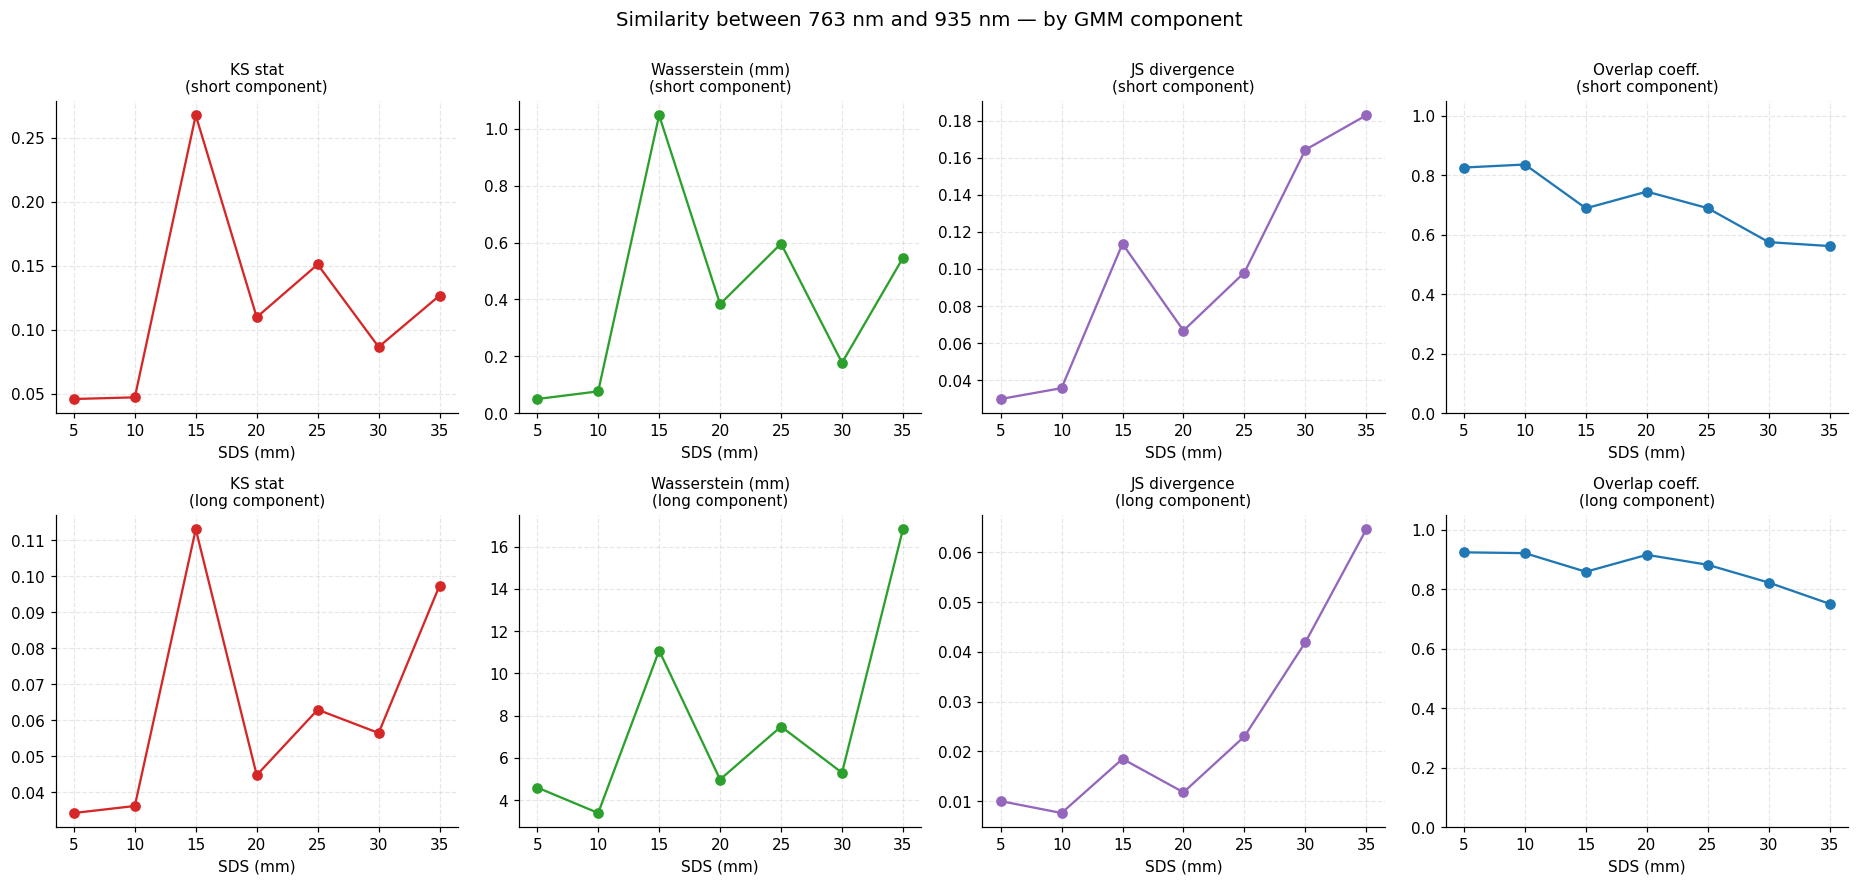

In [ ]:
# Visualize the split similarity metrics
def plot_split_similarity(split_sim):
    fig, axes = plt.subplots(2, 4, figsize=(17, 8))
    metrics = ['KS stat', 'Wasserstein (mm)', 'JS divergence', 'Overlap coeff.']
    colors  = ['C3', 'C2', 'C4', 'C0']

    for row, component in enumerate(['short', 'long']):
        sub = split_sim[split_sim['Component'] == component]
        for col, (metric, c) in enumerate(zip(metrics, colors)):
            ax = axes[row, col]
            ax.plot(sub['SDS (mm)'], sub[metric], 'o-', color=c)
            ax.set_xlabel('SDS (mm)')
            ax.set_title(f'{metric}\n({component} component)', fontsize=10)
            if metric == 'Overlap coeff.':
                ax.set_ylim(0, 1.05)
    plt.suptitle('Similarity between 763 nm and 935 nm — by GMM component', fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()


plot_split_similarity(split_sim)
